# ACCESS-OM3 MC 25km JRA RYF Scaling

End -to-end pipeline generating scaling plots for the [ACCESS-OM3 MC 25km JRA RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_25km_jra_ryf).


In [1]:
%load_ext autoreload
%autoreload 2

# Record package versions for future reference
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling", "payu", "experiment_generator", "experiment_runner"):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.5.dev3+g45c8354dc
access.profiling: 0.2.dev39+g4e244fb8b
payu: 1.3.6
experiment_generator: 0.10.3.dev1+g93564c8e5
experiment_runner: 0.3.2


## Setup

The following variables control where the configurations and model run outputs are saved.

In [2]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

work_path = f"/scratch/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive"

# Define the configuration
GLOBAL_GRID = Domain(shape=(1440, 1152))
OM3_MC_25KM = OM3Configuration(
    name="MC-25km",
    ocean=GLOBAL_GRID,
    sea_ice=GLOBAL_GRID,
    atmosphere=GLOBAL_GRID,
    runoff=GLOBAL_GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(work_path), archive_dir=Path(archive_path), configuration=OM3_MC_25KM)
om3_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-om3-configs.git", commit="29ccf118e5bdc09a246d339ac64f330c5b2e9473")

## Generate Experiments

In [3]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

num_nodes_list = [1.0, 2.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0, 26.0, 28.0, 32.0, 36.0, 40.0]
cores_per_node = 104

# Define how the cores should be allocated to the components
def allocation_strategy(num_nodes):
    if num_nodes >= 12.0:
        waste_frac = 0.01
        cice_ratio = 1.5
        step = 15
    elif num_nodes >= 4.0:
        waste_frac = 0.01
        cice_ratio = 2.0
        step = 5
    else:
        waste_frac = 0.01
        cice_ratio = 2.5
        step = 2
    return RootAllocation(
        subcomponents={
            "ocn": FreeAllocation(min_core_fraction=0.85, core_step=step),
            "shared": FreeAllocation(min_core_fraction=0.05, core_step=step,
                subcomponents={
                    "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=cice_ratio),),),
                    "cpl": WholeRangeAllocation(),
                    "rof": WholeRangeAllocation(),
                    "atm": WholeRangeAllocation(),
                },
            ),
        },
        local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=waste_frac),),
        group_constraints=(
           RankRatioGroupConstraint(name_a="ocn", name_b="shared", min_ratio=9.0),
           RankRatioGroupConstraint(name_a="shared", name_b="ocn", min_ratio=0.1),
       ),
    )

# Write how many layouts are going to be generated for each number of nodes
from access.config.parallel_layouts import iter_layouts
for num_nodes in num_nodes_list:
    layouts = list(iter_layouts(OM3_MC_25KM.parallel_component, int(num_nodes*cores_per_node), allocations=allocation_strategy(num_nodes)))
    print(f"Num nodes: {num_nodes}, Num layouts: {len(layouts)}")

Num nodes: 1.0, Num layouts: 1
Num nodes: 2.0, Num layouts: 4
Num nodes: 4.0, Num layouts: 3
Num nodes: 8.0, Num layouts: 4
Num nodes: 12.0, Num layouts: 3
Num nodes: 16.0, Num layouts: 2
Num nodes: 20.0, Num layouts: 2
Num nodes: 24.0, Num layouts: 7
Num nodes: 26.0, Num layouts: 6
Num nodes: 28.0, Num layouts: 6
Num nodes: 32.0, Num layouts: 5
Num nodes: 36.0, Num layouts: 8
Num nodes: 40.0, Num layouts: 7


In [4]:
# Generate the configuration and write to file
run_length = 2 #
run_units = "nmonths" # what nuopc.runconfig can understand as the value for both restart_option and stop_option
control_options = {
            "config.yaml": {
                "modules": {
                    "use": ["/g/data/vk83/modules"],
                    "load": ["access-om3/2026.05.004"],
                },
                "mem": "REMOVE",
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
                "collate": "REMOVE",
                "archive": "REMOVE",
            },
            "MOM_input": {
                "AUTO_MASKTABLE": "True",
                "MASKTABLE": "REMOVE",
                "LAYOUT": "REMOVE",
                "IO_LAYOUT": "REMOVE",
            },
            "nuopc.runconfig": {
                "CLOCK_attributes": {
                    "stop_n": run_length,
                    "stop_option": run_units,
                    "restart_n": run_length,
                    "restart_option": run_units,
                },
            },
        }

def walltime_fn(num_nodes):
    return min(2.0 * 27.0/num_nodes, 24) # use a 2 hrs time for 27-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=cores_per_node, walltime=walltime_fn, allocations=allocation_strategy)

-- Test directory /scratch/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf already exists!
-- Test dir: /scratch/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/config already exists, hence not cloning https://github.com/ACCESS-NRI/access-om3-configs.git
Checked out branch: ctrl
laboratory path:  /scratch/tm70/mo1833/access-om3
binary path:  /scratch/tm70/mo1833/access-om3/bin
input path:  /scratch/tm70/mo1833/access-om3/input
work path:  /scratch/tm70/mo1833/access-om3/work
archive path:  /scratch/tm70/mo1833/access-om3/archive
Found experiment archive: /scratch/tm70/mo1833/access-om3/archive/config-ctrl-27a10eae
No prior restart path provided. Skip adding parent branch time to metadata.
Removed archive symlink to /scratch/tm70/mo1833/access-om3/archive/om3-layout_MC-25km_atm_405_cpl_405_ice_27x15_ocn_3750_rof_405
Added archive symlink to /scratch/tm70/mo1833/access-om3/archive/config-ctrl-27a10eae
-- Branch om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10 already exists, switching 

## Run experiments

Next we run the experiments

In [5]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [6]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count  (ignoring layouts that failed)
best_experiments = om3_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

Experiment 'om3-layout_MC-25km_atm_10_cpl_10_ice_5x2_ocn_94_rof_10' is not completed (status: RUNNING). Skipping parsing profiling data.


['om3-layout_MC-25km_atm_20_cpl_20_ice_5x4_ocn_188_rof_20',
 'om3-layout_MC-25km_atm_40_cpl_40_ice_10x4_ocn_375_rof_40',
 'om3-layout_MC-25km_atm_80_cpl_80_ice_10x8_ocn_745_rof_80',
 'om3-layout_MC-25km_atm_120_cpl_120_ice_12x10_ocn_1125_rof_120',
 'om3-layout_MC-25km_atm_165_cpl_165_ice_15x11_ocn_1485_rof_165',
 'om3-layout_MC-25km_atm_195_cpl_195_ice_13x15_ocn_1875_rof_195',
 'om3-layout_MC-25km_atm_240_cpl_240_ice_20x12_ocn_2250_rof_240',
 'om3-layout_MC-25km_atm_270_cpl_270_ice_18x15_ocn_2430_rof_270',
 'om3-layout_MC-25km_atm_285_cpl_285_ice_19x15_ocn_2610_rof_285',
 'om3-layout_MC-25km_atm_330_cpl_330_ice_22x15_ocn_2970_rof_330',
 'om3-layout_MC-25km_atm_360_cpl_360_ice_18x20_ocn_3360_rof_360',
 'om3-layout_MC-25km_atm_390_cpl_390_ice_26x15_ocn_3750_rof_390']

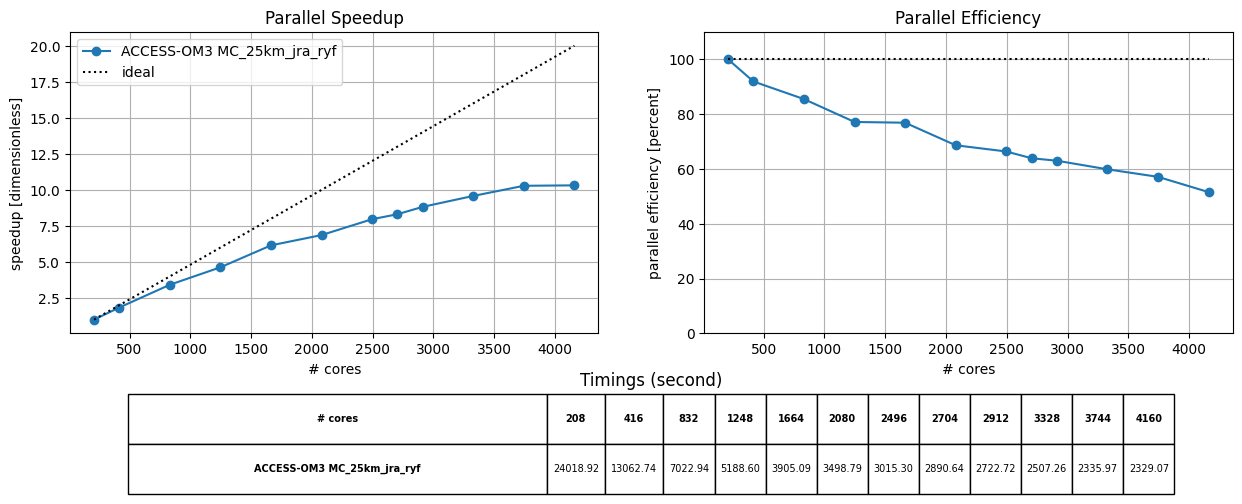

In [7]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu"],
    regions=[
        ["payu_model_run_duration_seconds"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "ACCESS-OM3 MC_25km_jra_ryf",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

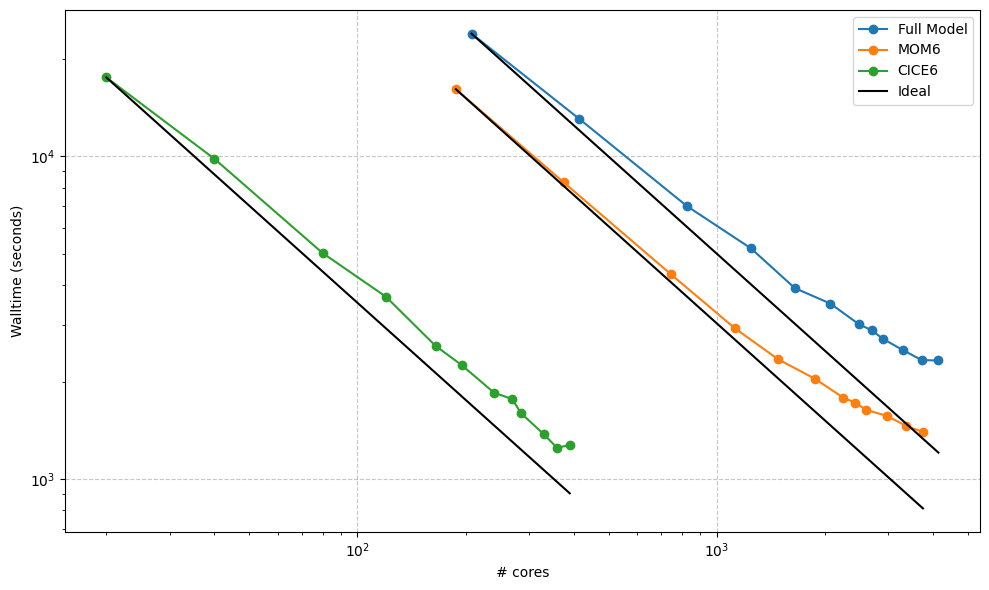

In [8]:
# Per-component scaling

from access.profiling.manager import RegionGroup
fig2 = om3_profiling.plot_component_scaling_data(
    [
        RegionGroup("payu", ["payu_model_run_duration_seconds"], component="ACCESS-OM3 MC-25km"),
        RegionGroup("MOM6", ["Ocean"], component="ocn"),
        RegionGroup("CICE6", ["Total"], component="ice"),
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
    ylabel="Walltime (seconds)",
)

## Summary

We have presented the strong scaling results for the [25km RYF configuration](https://github.com/ACCESS-NRI/access-om3-configs/tree/dev-MC_25km_jra_ryf) of ACCESS-OM3. The underlying components are MOM6 for ocean, CICE6 for the ice model, using the NUOPC coupler from ESMF. The atmosphere and runoff are applied as forcings. Atmosphere, coupler, runoff, and CICE all share the same cores and run concurrently with MOM6. The released configuration for ACCESS-OM3 100km RYF configuration uses 5-nodes on the `normalsr` queue with `sapphirerapids` cpus, where each node contains 104 cores. The table shows the raw data from the runs corresponding to each of the components, and the overall model runtime. The columns represent 12, 16, 20, 24, 26, 28, 32, 26 and 40 node configs.

We have varied the number of nodes between 12 and 40, and for each case, we have tested several options with different partitioning of the total number of available cores between the two components. In the plots above, we have presented the best performing configuration for each case. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the single node config (left) and computational efficiency relative to the single node config (right). The plot on the left shows that the ACCESS-OM3 model has linear speedup at 16 nodes, ~1.8x at 26 nodes, eventually plateuing at ~2.2x above 36 nodes. We ob serve a similar effect in the computational efficiency as well - the efficiency is ~near ideal for 16 nodes, then stays above 80% through 28 nodes, and drops to 65% for 40 nodes. CICE shows near-perfect scaling through 36 nodes, only dropping at the 40 node setup. It is to be expected that any code will plateau when the serial part (potentially from synchronisation) starts to dominate (Amdahl's law). In addition, due to the concurrent running of the two components, we expect that this drop-off is partially from imperfect loadbalancing, and further investigation is required to improve the scaling for running ACCESS-OM3 >= 28 nodes. 

# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments(exclude_files=[
        "*.nc",
        ])

Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_270_cpl_270_ice_15x18_ocn_2430_rof_270.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_360_cpl_360_ice_18x20_ocn_3360_rof_360.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_345_cpl_345_ice_23x15_ocn_3375_rof_345.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_20_cpl_20_ice_4x5_ocn_188_rof_20.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/om3-layout_MC-25km_atm_195_cpl_195_ice_15x13_ocn_1875_rof_195.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-OM3/MC_25km_jra_ryf/archive/